# Homework 0: Prism Dispersion and the Dark Side of the Moon

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# snells law
def refractive_index(x: float):
    """Computes index of refraction based on wavelength. x: wavelength in micrometers."""
    return 1.50 + 0.004/x**2


def prism_refraction(incidence_angle: float, wavelength: float, path: np.array):
    """
    Y-coordinates of a ray through an equilateral triangular prism.

    Parameters
    ----------
    incidence_angle : float
        Angle of incidence at the left face (degrees, measured from surface normal).
    wavelength : float
        Wavelength in micrometers.
    path : array-like
        X-coordinates spanning the full path; divided into 3 equal sections.

    Returns
    -------
    np.ndarray
        Y-coordinates along the full path (incoming, inside prism, outgoing).
    """
    refractive_idx = refractive_index(wavelength)
    # light enters "thicker" medium
    refraction_1 = np.rad2deg(np.arcsin(np.sin(np.deg2rad(incidence_angle))/refractive_idx))
    incidence_angle_2 = 90 - (180 - 60 - (90 - refraction_1))
    # light exits "thicker" medium
    refraction_2 = np.rad2deg(np.arcsin(np.sin(np.deg2rad(incidence_angle_2))*refractive_idx))

    # split path into 3 parts
    section_len = int(len(path)/3)

    path_section = path[:section_len]

    y1 = (path_section - path_section[-1]) * np.tan(np.deg2rad(incidence_angle - 30))
    y2 = path_section*(-1/np.tan(np.deg2rad(60+refraction_1)))
    y3 = path_section*np.tan(np.deg2rad(30-refraction_2)) + y2[-1]

    return np.concat([y1,y2,y3])

COLOR_WAVELENGTHS = {
    "violet":0.4,
    "blue":0.45,
    "cyan":0.5,
    "green":0.55,
    "yellow":0.58,
    "orange":0.62,
    "red":0.7,
}

### Model verification
To verify my model works correctly, I will test a 180 deg incidence angle. For such a case, the light should not pass through the prism. Therefore the model should return a straight line.

/var/folders/ys/qmftlyyx3dj63021dv4205g80000gn/T/ipykernel_81593/648226766.py:30: RuntimeWarning: invalid value encountered in arcsin
  refraction_2 = np.rad2deg(np.arcsin(np.sin(np.deg2rad(incidence_angle_2))*refractive_idx))


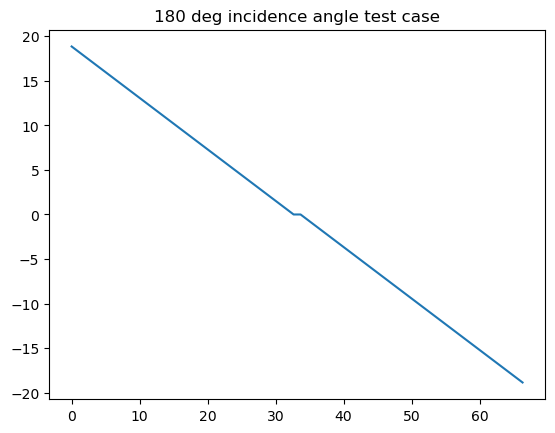

In [7]:
path = np.linspace(0,100,99)
test_180 = prism_refraction(incidence_angle=180,wavelength=0.5,path=path)
plt.plot(path,test_180)
plt.title("180 deg incidence angle test case")
plt.savefig('figures/test_case.png')

### Physical consistency based on wavelength dependence of refractive index
Since there is a wavelength dependence to the refractive index, I expect the depiction on the cover of The Dark Side of the Moon to be correct. Since the color red has a longer wavelength than blue/violet, its refractive index will be relatively smaller. Therefore when the light passes through the prism, the blue light will be refracted more and end up towards the bottom (with red towards the top).

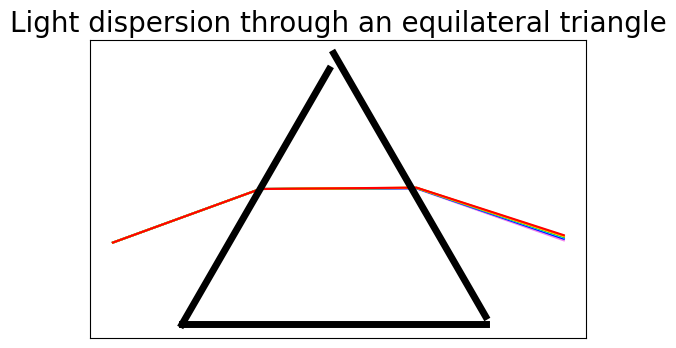

In [8]:
path = np.linspace(0,100,99)

fig, ax = plt.subplots()
for color, wavelength in COLOR_WAVELENGTHS.items():
    color_path = prism_refraction(incidence_angle=50,wavelength=wavelength,path=path)

    ax.plot(path,color_path,color=color)

ax.set_title('Light dispersion through an equilateral triangle',fontsize=20)

b1 = -1*path[:33][-1]*np.tan(np.deg2rad(60))
b2 = path[33:66][-1]*np.tan(np.deg2rad(60))   # symmetric with left face: right face passes through (x2[-1], 0)

tri_x = np.linspace(0,100,99)
side1 = np.tan(np.deg2rad(60))*tri_x+b1
side2 = -1*np.tan(np.deg2rad(60))*tri_x+b2

top_cross_over_idx = np.argmin(np.abs(side1 - side2))
left_cross_over_idx = np.argmin(np.abs(side1+30))
right_cross_over_idx = np.argmin(np.abs(side2+30))

ax.plot(tri_x[left_cross_over_idx:top_cross_over_idx],side1[left_cross_over_idx:top_cross_over_idx],color='k',linewidth = 5)
ax.plot(tri_x[top_cross_over_idx:right_cross_over_idx],side2[top_cross_over_idx:right_cross_over_idx],color='k',linewidth = 5)
ax.plot(tri_x[left_cross_over_idx:right_cross_over_idx],-30*np.ones(len(tri_x[left_cross_over_idx:right_cross_over_idx])),color='k',linewidth = 5)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])

plt.savefig('figures/light_through_prism.png')

### Physical consistency based on ray tracing figure
As expected, the light is sorted based on wavelength with the longer wavelengths above the shorter wavelengths. The longer wavelengths are refracted less from their original path due to the inverse wavelength dependence of the refractive index. This is consistent with the album cover.

### AI Usage
For this assignment, I used claude code to:
- generate the equilateral triangle in Figure 2
- generate the readme for the repo
- generate doc strings in the functions
- check assignment for correctness (logic and spelling)